PHASE 1: 1D sweep over N0 (with FishForcing=0.5)


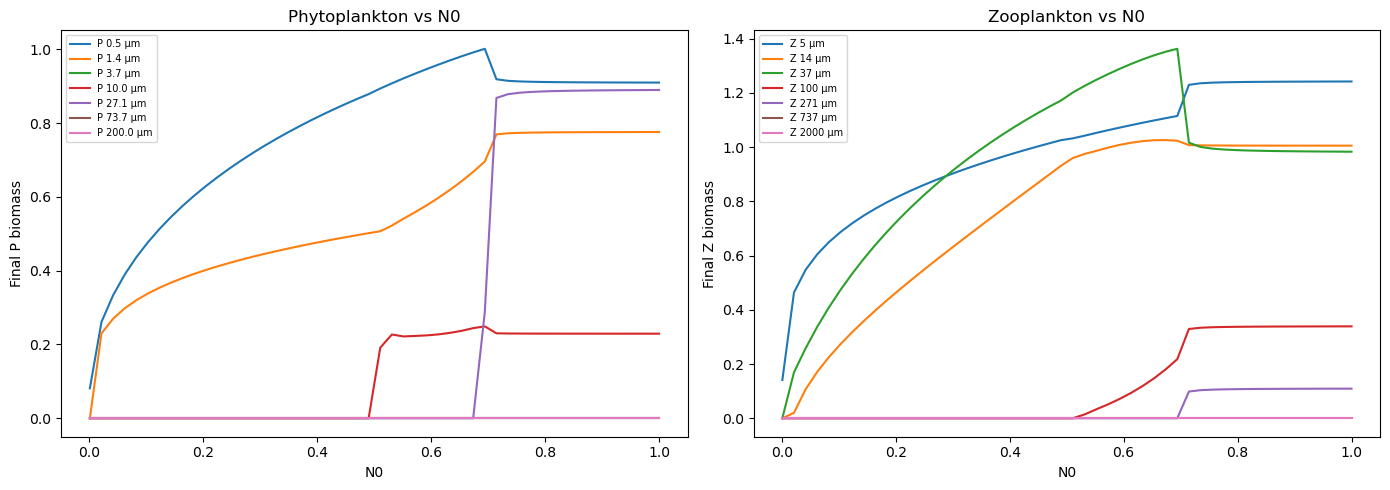


Largest P class (200.0 µm) peaks at N0 = 1.00
  Fraction of total P: 0.000
  Absolute biomass:    0.0000


In [3]:
"""
NPxZxf regime exploration
==========================
Phase 1: 1D sweep over N0 to find large-P-dominated baseline
Phase 2: 2D scans (N0 × FishForcing, N0 × KsZ)
Phase 3: Dominance diagnostics
"""

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from xso.parscans import run_xso_parscan

# Import for 1D exploration and reference values
from npxzxf_models import run_model_test, phyto_esd, zoo_esd

n_P = len(phyto_esd)
n_Z = len(zoo_esd)

# =====================================================================
# PHASE 1: Quick 1D sweep to find large-P baseline
# =====================================================================

print("=" * 60)
print("PHASE 1: 1D sweep over N0 (with FishForcing=0.5)")
print("=" * 60)

N0_vals = np.linspace(0.001, 1, 50)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

final_P = np.zeros((len(N0_vals), n_P))
final_Z = np.zeros((len(N0_vals), n_Z))

for idx, n0 in enumerate(N0_vals):
    out = run_model_test(
        {'N0__value': n0, 'FishForcing__value': 0.5},
        time=np.arange(0, 1000)
    )
    final_P[idx, :] = out.Phytoplankton__biomass.isel(time=-1).values
    final_Z[idx, :] = out.Zooplankton__biomass.isel(time=-1).values

# Plot final biomass per size class vs N0
for j in range(n_P):
    axes[0].plot(N0_vals, final_P[:, j], label=f'P {phyto_esd[j]:.1f} µm')
axes[0].set_xlabel('N0')
axes[0].set_ylabel('Final P biomass')
axes[0].set_title('Phytoplankton vs N0')
axes[0].legend(fontsize=7)

for j in range(n_Z):
    axes[1].plot(N0_vals, final_Z[:, j], label=f'Z {zoo_esd[j]:.0f} µm')
axes[1].set_xlabel('N0')
axes[1].set_ylabel('Final Z biomass')
axes[1].set_title('Zooplankton vs N0')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig('phase1_1d_sweep.png', dpi=150)
plt.show()

# Identify N0 where largest P class has max relative share
P_fracs = final_P / (final_P.sum(axis=1, keepdims=True) + 1e-12)
largest_P_frac = P_fracs[:, -1]
best_idx = np.argmax(largest_P_frac)
print(f"\nLargest P class ({phyto_esd[-1]:.1f} µm) peaks at N0 = {N0_vals[best_idx]:.2f}")
print(f"  Fraction of total P: {largest_P_frac[best_idx]:.3f}")
print(f"  Absolute biomass:    {final_P[best_idx, -1]:.4f}")



In [ ]:

# =====================================================================
# PHASE 2: 2D parameter scans
# =====================================================================

print("\n" + "=" * 60)
print("PHASE 2: 2D scans (20×20, IVP to t=1000)")
print("=" * 60)

# --- Scan 1: N0 × FishForcing ---
print("\nRunning Scan 1: N0 × FishForcing ...")
N0_scan = np.linspace(0.01, 20., 20)
FF_scan = np.linspace(0.0, 2.0, 20)

results_NF = run_xso_parscan(
    model_file_name='npxzxf_models',
    model_name='model',
    model_setup_name='model_setup_ivp_1k',
    param_name='N0__value',
    param_values=N0_scan,
    param_name2='FishForcing__value',
    param_values2=FF_scan,
    processes=20,
)
if results_NF is None:
    raise RuntimeError("Scan 1 (N0 × FishForcing) failed.")

# --- Scan 2: N0 × KsZ ---
print("\nRunning Scan 2: N0 × KsZ ...")
KsZ_scan = np.linspace(0.1, 10.0, 20)

results_NK = run_xso_parscan(
    model_file_name='npxzxf_models',
    model_name='model',
    model_setup_name='model_setup_ivp_1k',
    param_name='N0__value',
    param_values=N0_scan,
    param_name2='Grazing__KsZ',
    param_values2=KsZ_scan,
    processes=20,
)
if results_NK is None:
    raise RuntimeError("Scan 2 (N0 × KsZ) failed.")


# =====================================================================
# PHASE 3: Diagnostic plots
# =====================================================================

print("\n" + "=" * 60)
print("PHASE 3: Diagnostics")
print("=" * 60)


def compute_dominance_metrics(ds, p1_name, p2_name):
    """Extract dominance metrics from a 2D parscan result.

    Returns
    -------
    dominant_P_idx : 2D array of index of dominant P class
    P_slope : 2D array of log-log spectral slope
    total_P, total_Z : 2D arrays of total biomass
    """
    # Final timestep
    P_final = ds['Phytoplankton__biomass'].isel(time=-1)  # (p1, p2, phyto)
    Z_final = ds['Zooplankton__biomass'].isel(time=-1)    # (p1, p2, zoo)

    # Dominant P class (argmax along phyto dim)
    dominant_P_idx = P_final.argmax(dim='phyto').values

    # Total biomass
    total_P = P_final.sum(dim='phyto').values
    total_Z = Z_final.sum(dim='zoo').values

    # Spectral slope: linear regression of log(B) vs log(ESD)
    log_esd = np.log10(phyto_esd)
    P_slope = np.full(dominant_P_idx.shape, np.nan)
    for i in range(P_final.shape[0]):
        for j in range(P_final.shape[1]):
            b = P_final.values[i, j, :]
            mask = b > 1e-6
            if mask.sum() >= 2:
                P_slope[i, j] = np.polyfit(log_esd[mask], np.log10(b[mask]), 1)[0]

    return dominant_P_idx, P_slope, total_P, total_Z


def plot_2d_diagnostics(ds, p1_name, p1_vals, p2_name, p2_vals, scan_label):
    """Plot 4-panel diagnostic for one 2D scan."""
    dom_idx, slope, tot_P, tot_Z = compute_dominance_metrics(ds, p1_name, p2_name)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Regime map: {scan_label}', fontsize=14)

    # Panel 1: Dominant P size class
    cmap_dom = plt.cm.viridis
    bounds = np.arange(-0.5, n_P + 0.5, 1)
    norm_dom = BoundaryNorm(bounds, cmap_dom.N)
    im0 = axes[0, 0].pcolormesh(p1_vals, p2_vals, dom_idx.T,
                                 cmap=cmap_dom, norm=norm_dom)
    cb0 = plt.colorbar(im0, ax=axes[0, 0], ticks=range(n_P))
    cb0.set_ticklabels([f'{e:.1f}' for e in phyto_esd])
    axes[0, 0].set_title('Dominant P class (µm ESD)')

    # Panel 2: Spectral slope
    im1 = axes[0, 1].pcolormesh(p1_vals, p2_vals, slope.T, cmap='RdBu_r',
                                 vmin=-3, vmax=3)
    plt.colorbar(im1, ax=axes[0, 1])
    axes[0, 1].set_title('P spectral slope (log B vs log ESD)')

    # Panel 3: Total P biomass
    im2 = axes[1, 0].pcolormesh(p1_vals, p2_vals, np.log10(tot_P.T + 1e-8),
                                 cmap='YlGn')
    plt.colorbar(im2, ax=axes[1, 0])
    axes[1, 0].set_title('log₁₀(Total P biomass)')

    # Panel 4: Total Z biomass
    im3 = axes[1, 1].pcolormesh(p1_vals, p2_vals, np.log10(tot_Z.T + 1e-8),
                                 cmap='YlOrRd')
    plt.colorbar(im3, ax=axes[1, 1])
    axes[1, 1].set_title('log₁₀(Total Z biomass)')

    for ax in axes.flat:
        ax.set_xlabel(p1_name)
        ax.set_ylabel(p2_name)

    plt.tight_layout()
    plt.savefig(f'regime_map_{scan_label}.png', dpi=150)
    plt.show()


# --- Plot Scan 1: N0 × FishForcing ---
plot_2d_diagnostics(results_NF, 'N0__value', N0_scan,
                    'FishForcing__value', FF_scan, 'N0_x_FishForcing')

# --- Plot Scan 2: N0 × KsZ ---
plot_2d_diagnostics(results_NK, 'N0__value', N0_scan,
                    'Grazing__KsZ', KsZ_scan, 'N0_x_KsZ')


# =====================================================================
# BONUS: Size-spectrum snapshots at interesting corners
# =====================================================================

print("\n" + "=" * 60)
print("BONUS: Size-spectrum bar plots at regime corners")
print("=" * 60)

corner_cases = {
    'Low N0, No fish':     {'N0__value': 1.0,  'FishForcing__value': 0.0},
    'High N0, No fish':    {'N0__value': 18.0, 'FishForcing__value': 0.0},
    'Low N0, High fish':   {'N0__value': 1.0,  'FishForcing__value': 1.5},
    'High N0, High fish':  {'N0__value': 18.0, 'FishForcing__value': 1.5},
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (label, params) in zip(axes.flat, corner_cases.items()):
    out = run_model_test(params, time=np.arange(0, 1000))
    P_end = out.Phytoplankton__biomass.isel(time=-1).values
    Z_end = out.Zooplankton__biomass.isel(time=-1).values

    x_P = np.arange(n_P)
    x_Z = np.arange(n_P, n_P + n_Z)
    ax.bar(x_P, P_end, color='green', alpha=0.7, label='P')
    ax.bar(x_Z, Z_end, color='orange', alpha=0.7, label='Z')
    ax.set_xticks(np.arange(n_P + n_Z))
    ax.set_xticklabels(
        [f'P{phyto_esd[i]:.0f}' for i in range(n_P)] +
        [f'Z{zoo_esd[i]:.0f}' for i in range(n_Z)],
        rotation=45, fontsize=7
    )
    ax.set_ylabel('Biomass (mmol N m⁻³)')
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('corner_case_spectra.png', dpi=150)
plt.show()

print("\nDone. Saved: phase1_1d_sweep.png, regime_map_*.png, corner_case_spectra.png")

PHYTOPLANKTON PARAMETERS
  ESD (µm)     mu_max        K_s       mort   w_P (fish)
-------------------------------------------------------
      0.50     3.3636     0.0595     0.1000       0.0000
      1.36     1.5905     0.1257     0.1000       0.0000
      3.68     0.7521     0.2659     0.1000       0.0000
     10.00     0.3557     0.5623     0.1000       0.0000
     27.14     0.1682     1.1892     0.1000       0.0000
     73.68     0.0795     2.5149     0.1000       0.0000
    200.00     0.0376     5.3183     0.1000       0.3000

mu_max ratio (smallest/largest): 89.4x
K_s ratio   (largest/smallest):  89.4x

ZOOPLANKTON PARAMETERS
  ESD (µm)      I_max        GGE       mort   w_Z (fish)
-------------------------------------------------------
       5.0    27.8949     0.3500     0.0500       0.0000
      13.6    17.2727     0.3167     0.0500       0.0000
      36.8    10.6953     0.2833     0.0500       0.0035
     100.0     6.6226     0.2500     0.0500       0.0355
     271.4     4.10

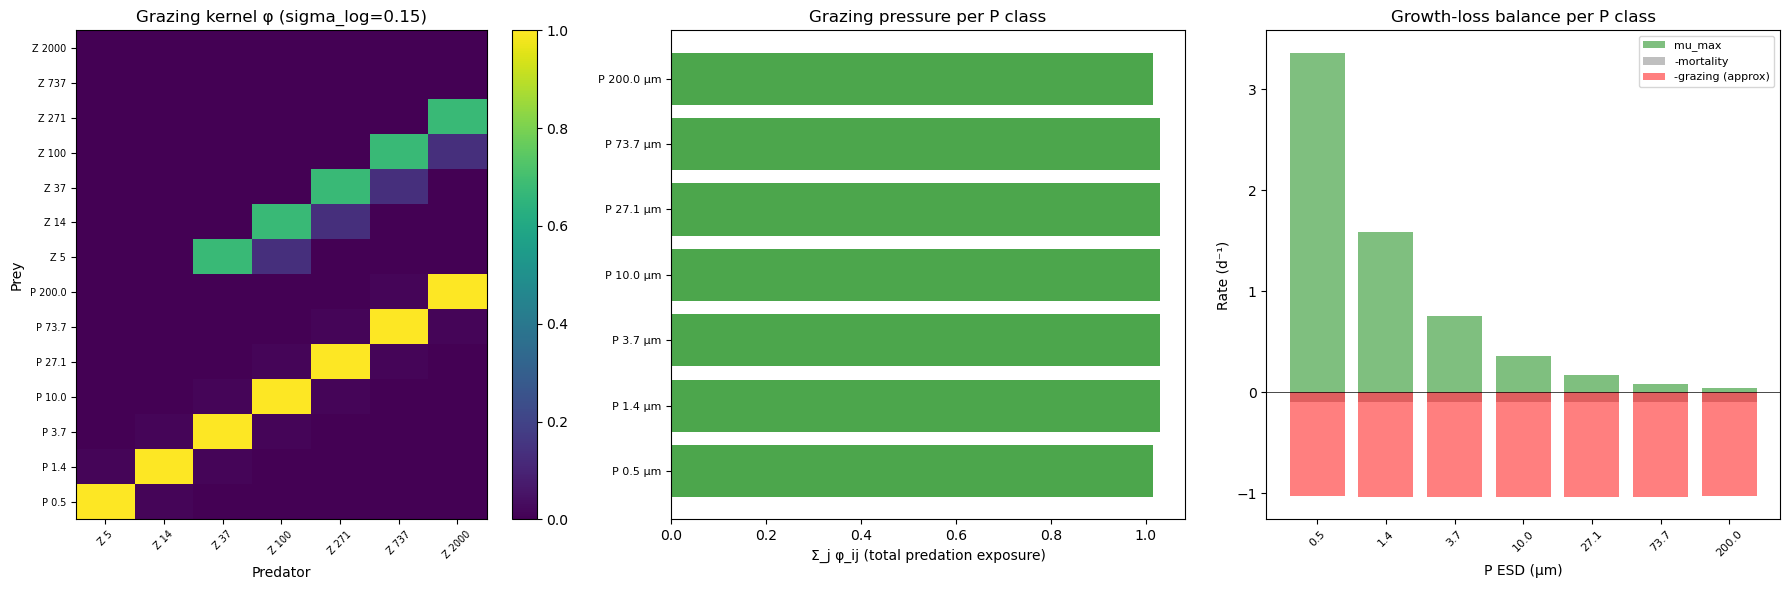

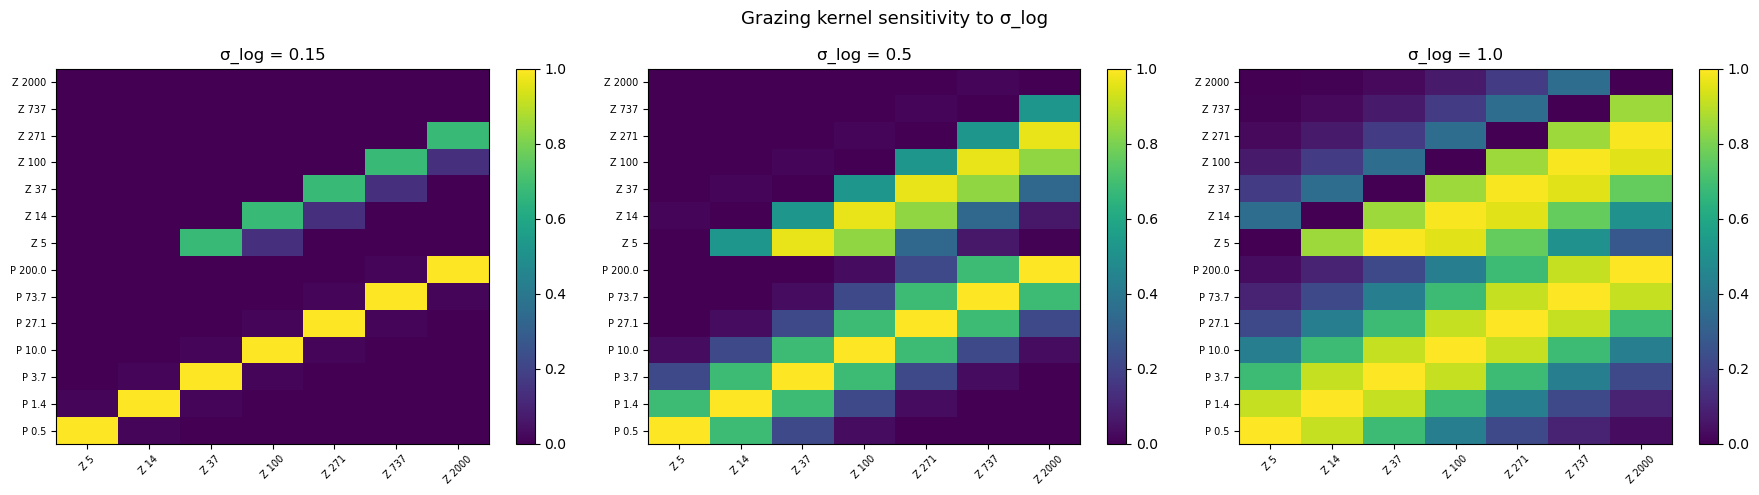


COMPARISON: P range 2–200 µm (vs current 0.5–200 µm)

  ESD (µm)     mu_max   mu_max_old        K_s    K_s_old
-------------------------------------------------------
      2.00     1.1892       3.3636     0.1682     0.0595
      4.31     0.6687       1.5905     0.2991     0.1257
      9.28     0.3761       0.7521     0.5318     0.2659
     20.00     0.2115       0.3557     0.9457     0.5623
     43.09     0.1189       0.1682     1.6818     1.1892
     92.83     0.0669       0.0795     2.9907     2.5149
    200.00     0.0376       0.0376     5.3183     5.3183

mu_max ratio (smallest/largest): 31.6x (was 89.4x)
K_s ratio   (largest/smallest):  31.6x (was 89.4x)

Done. Saved: diagnostic_params_kernel.png, diagnostic_sigma_log_comparison.png


In [4]:
"""
Diagnostic: inspect allometric parameters and grazing kernel
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from npxzxf_models import (
    phyto_esd, zoo_esd, mu_max, K_s, m_P,
    I_max, gge, m_Z, phiPZ, w_P, w_Z,
)
from allometric_params import (
    generate_size_classes, compute_phyto_params, compute_zoo_params,
    compute_grazing_kernel,
)

n_P = len(phyto_esd)
n_Z = len(zoo_esd)

# =====================================================================
# 1. Print all current parameter values
# =====================================================================

print("=" * 70)
print("PHYTOPLANKTON PARAMETERS")
print("=" * 70)
print(f"{'ESD (µm)':>10} {'mu_max':>10} {'K_s':>10} {'mort':>10} {'w_P (fish)':>12}")
print("-" * 55)
for i in range(n_P):
    print(f"{phyto_esd[i]:10.2f} {mu_max[i]:10.4f} {K_s[i]:10.4f} "
          f"{m_P[i]:10.4f} {w_P[i]:12.4f}")

print(f"\nmu_max ratio (smallest/largest): {mu_max[0]/mu_max[-1]:.1f}x")
print(f"K_s ratio   (largest/smallest):  {K_s[-1]/K_s[0]:.1f}x")

print("\n" + "=" * 70)
print("ZOOPLANKTON PARAMETERS")
print("=" * 70)
print(f"{'ESD (µm)':>10} {'I_max':>10} {'GGE':>10} {'mort':>10} {'w_Z (fish)':>12}")
print("-" * 55)
for i in range(n_Z):
    print(f"{zoo_esd[i]:10.1f} {I_max[i]:10.4f} {gge[i]:10.4f} "
          f"{m_Z:10.4f} {w_Z[i]:12.4f}")

# =====================================================================
# 2. Visualize the grazing kernel
# =====================================================================

prey_labels = [f'P {e:.1f}' for e in phyto_esd] + [f'Z {e:.0f}' for e in zoo_esd]
pred_labels = [f'Z {e:.0f}' for e in zoo_esd]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 2a: Full preference matrix (heatmap)
ax = axes[0]
im = ax.imshow(phiPZ, aspect='auto', origin='lower', cmap='viridis')
ax.set_xticks(range(n_Z))
ax.set_xticklabels(pred_labels, rotation=45, fontsize=7)
ax.set_yticks(range(n_P + n_Z))
ax.set_yticklabels(prey_labels, fontsize=7)
ax.set_xlabel('Predator')
ax.set_ylabel('Prey')
ax.set_title(f'Grazing kernel φ (sigma_log=0.15)')
plt.colorbar(im, ax=ax)

# 2b: Effective grazing pressure on each P class (sum over predators)
ax = axes[1]
grazing_pressure_P = phiPZ[:n_P, :].sum(axis=1)
grazing_pressure_Z = phiPZ[n_P:, :].sum(axis=1)
ax.barh(range(n_P), grazing_pressure_P, color='green', alpha=0.7, label='on P')
ax.set_yticks(range(n_P))
ax.set_yticklabels([f'P {e:.1f} µm' for e in phyto_esd], fontsize=8)
ax.set_xlabel('Σ_j φ_ij (total predation exposure)')
ax.set_title('Grazing pressure per P class')

# 2c: Growth vs grazing balance for P
ax = axes[2]
# Net growth potential at saturating nutrients: mu_max - mortality - grazing_pressure * typical Z
typical_Z_biomass = 0.1
net_growth = mu_max - m_P - grazing_pressure_P * I_max.mean() * typical_Z_biomass
ax.bar(range(n_P), mu_max, color='green', alpha=0.5, label='mu_max')
ax.bar(range(n_P), -m_P, color='grey', alpha=0.5, label='-mortality')
ax.bar(range(n_P), -grazing_pressure_P * I_max.mean() * typical_Z_biomass,
       color='red', alpha=0.5, label='-grazing (approx)')
ax.axhline(0, color='k', lw=0.5)
ax.set_xticks(range(n_P))
ax.set_xticklabels([f'{e:.1f}' for e in phyto_esd], rotation=45, fontsize=8)
ax.set_xlabel('P ESD (µm)')
ax.set_ylabel('Rate (d⁻¹)')
ax.set_title('Growth-loss balance per P class')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('diagnostic_params_kernel.png', dpi=150)
plt.show()

# =====================================================================
# 3. Compare grazing kernels at different sigma_log
# =====================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, sig in zip(axes, [0.15, 0.5, 1.0]):
    phi_test = compute_grazing_kernel(phyto_esd, zoo_esd,
                                       theta_opt=10.0, sigma_log=sig)
    im = ax.imshow(phi_test, aspect='auto', origin='lower', cmap='viridis',
                   vmin=0, vmax=1)
    ax.set_xticks(range(n_Z))
    ax.set_xticklabels(pred_labels, rotation=45, fontsize=7)
    ax.set_yticks(range(n_P + n_Z))
    ax.set_yticklabels(prey_labels, fontsize=7)
    ax.set_title(f'σ_log = {sig}')
    plt.colorbar(im, ax=ax)

plt.suptitle('Grazing kernel sensitivity to σ_log', fontsize=13)
plt.tight_layout()
plt.savefig('diagnostic_sigma_log_comparison.png', dpi=150)
plt.show()

# =====================================================================
# 4. Same diagnostics with adjusted P range (2–200 µm)
# =====================================================================

print("\n" + "=" * 70)
print("COMPARISON: P range 2–200 µm (vs current 0.5–200 µm)")
print("=" * 70)

phyto_esd_new = generate_size_classes(7, 2.0, 200.0)
mu_max_new, K_s_new, m_P_new = compute_phyto_params(phyto_esd_new)

print(f"\n{'ESD (µm)':>10} {'mu_max':>10} {'mu_max_old':>12} {'K_s':>10} {'K_s_old':>10}")
print("-" * 55)
for i in range(7):
    print(f"{phyto_esd_new[i]:10.2f} {mu_max_new[i]:10.4f} {mu_max[i]:12.4f} "
          f"{K_s_new[i]:10.4f} {K_s[i]:10.4f}")

print(f"\nmu_max ratio (smallest/largest): {mu_max_new[0]/mu_max_new[-1]:.1f}x "
      f"(was {mu_max[0]/mu_max[-1]:.1f}x)")
print(f"K_s ratio   (largest/smallest):  {K_s_new[-1]/K_s_new[0]:.1f}x "
      f"(was {K_s[-1]/K_s[0]:.1f}x)")

print("\nDone. Saved: diagnostic_params_kernel.png, diagnostic_sigma_log_comparison.png")

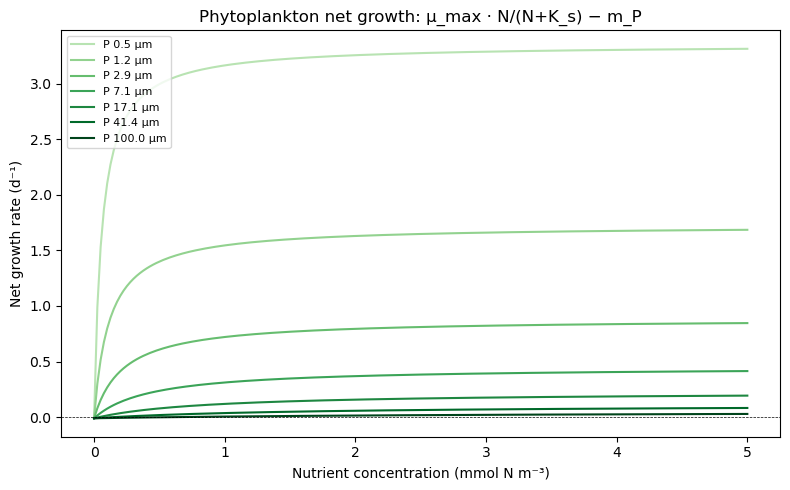

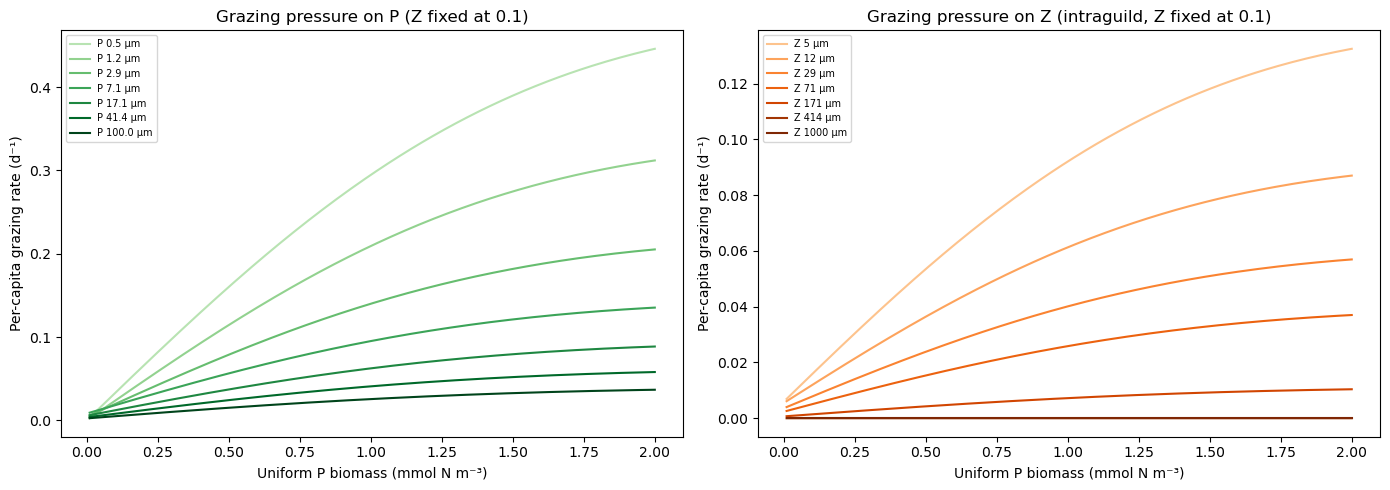

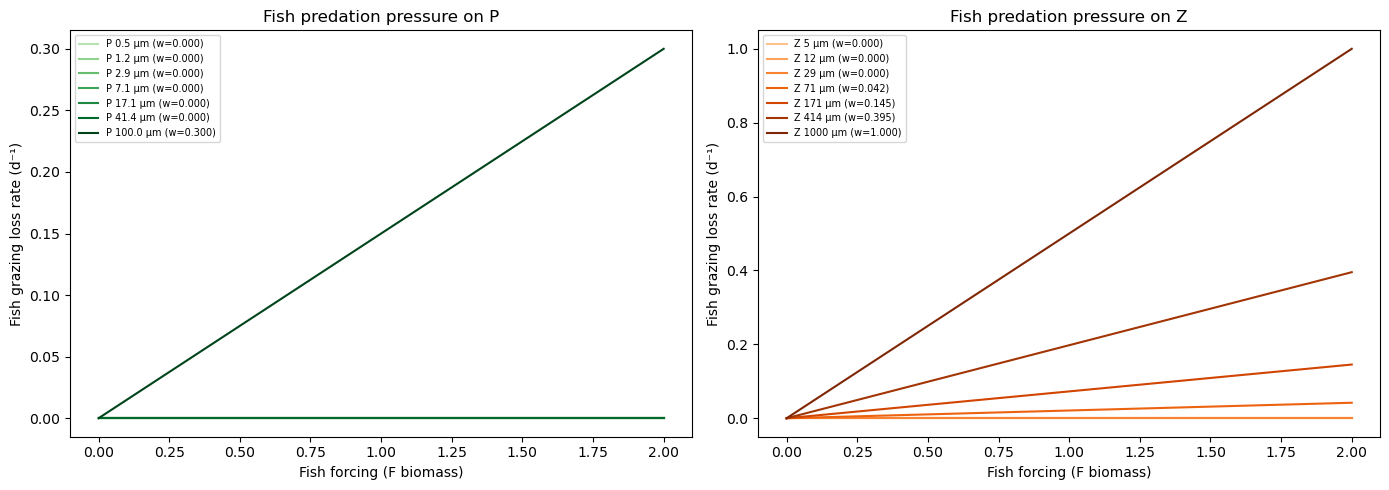

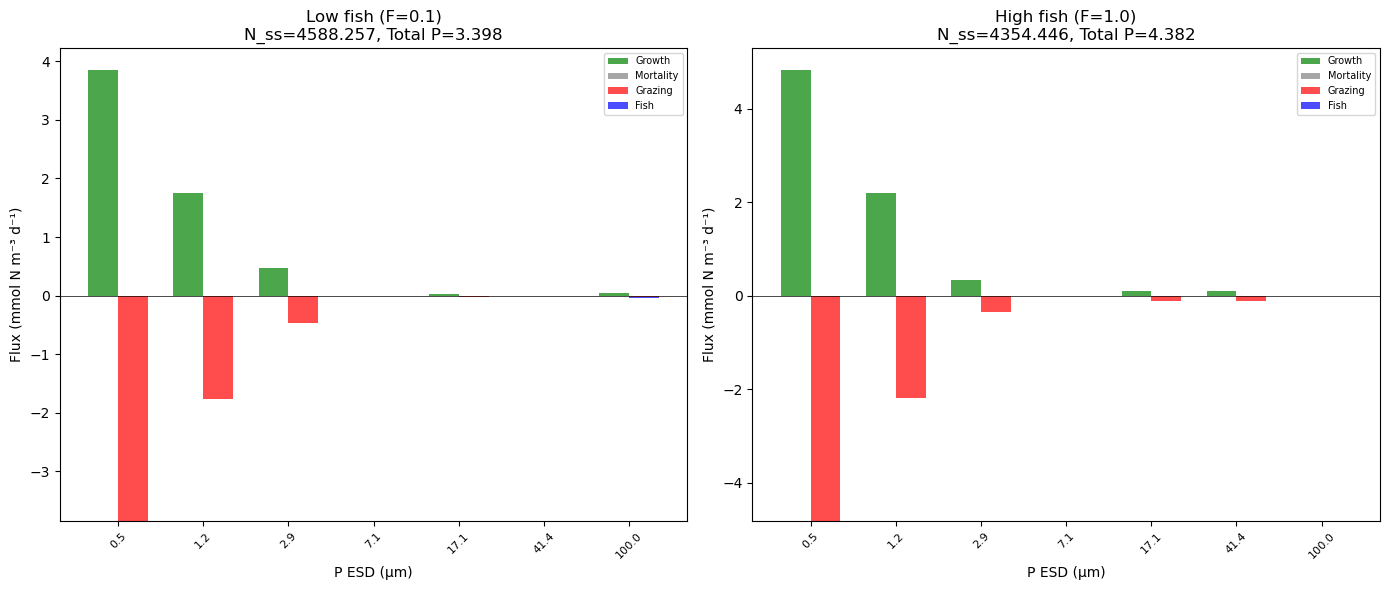

Done. Saved: tradeoff_1-4_*.png


In [2]:
"""
Diagnostic trade-off plots for NPxZxf model
=============================================
1. P net growth rate vs nutrient concentration
2. Total grazing pressure on prey vs uniform P concentration
3. Fish forcing effect on Z and P size spectra
4. Steady-state growth-loss budget per P size class
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

from npxzxf_models import (
    run_model_test,
    phyto_esd, zoo_esd,
    mu_max, K_s, m_P,
    I_max, gge, m_Z,
    phiPZ, w_P, w_Z,
    BASE_INPUT_VARS,
)

n_P = len(phyto_esd)
n_Z = len(zoo_esd)
KsZ = BASE_INPUT_VARS['Grazing']['KsZ']
fish_rate = BASE_INPUT_VARS['FishGrazing']['rate']

# Colour maps: consistent per size class across all plots
cmap_P = plt.cm.Greens(np.linspace(0.3, 1.0, n_P))
cmap_Z = plt.cm.Oranges(np.linspace(0.3, 1.0, n_Z))
cmap_all = np.vstack([cmap_P, cmap_Z])


# =====================================================================
# PLOT 1: P net growth vs nutrient concentration
# =====================================================================

N_range = np.linspace(0, 5, 200)

fig, ax = plt.subplots(figsize=(8, 5))
for i in range(n_P):
    gross = mu_max[i] * N_range / (N_range + K_s[i])
    net = gross - m_P[i]
    ax.plot(N_range, net, color=cmap_P[i],
            label=f'P {phyto_esd[i]:.1f} µm')

ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('Nutrient concentration (mmol N m⁻³)')
ax.set_ylabel('Net growth rate (d⁻¹)')
ax.set_title('Phytoplankton net growth: µ_max · N/(N+K_s) − m_P')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('tradeoff_1_P_net_growth.png', dpi=150)
plt.show()


# =====================================================================
# PLOT 2: Total grazing pressure on each prey item vs uniform P
# =====================================================================

P_uniform_range = np.linspace(0.01, 2.0, 200)
Z_fixed = np.full(n_Z, 0.1)

# For each P_uniform value, compute Type III grazing and sum over predators
# G_ij = Imax_j * Z_j * phi_ij * B_i * S_j / (S_j^2 + KsZ^2)
# Total on prey i = sum_j G_ij
# Grazing pressure = total on prey i / B_i  (per-capita rate)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2a: Total grazing pressure on P classes
grazing_pressure_P = np.zeros((len(P_uniform_range), n_P))
grazing_pressure_Z = np.zeros((len(P_uniform_range), n_Z))

for idx, P_val in enumerate(P_uniform_range):
    P_vec = np.full(n_P, P_val)
    biomass = np.concatenate([P_vec, Z_fixed])

    S_prey = np.sum(phiPZ * biomass[:, None], axis=0)  # (n_Z,)
    G = (I_max * Z_fixed * phiPZ * biomass[:, None]
         * S_prey / (S_prey ** 2 + KsZ ** 2))           # (n_P+n_Z, n_Z)

    # Per-capita grazing rate on each prey
    total_on_prey = np.sum(G, axis=1)  # (n_P + n_Z,)
    grazing_pressure_P[idx, :] = total_on_prey[:n_P] / (P_val + 1e-12)
    grazing_pressure_Z[idx, :] = total_on_prey[n_P:] / (Z_fixed + 1e-12)

ax = axes[0]
for i in range(n_P):
    ax.plot(P_uniform_range, grazing_pressure_P[:, i], color=cmap_P[i],
            label=f'P {phyto_esd[i]:.1f} µm')
ax.set_xlabel('Uniform P biomass (mmol N m⁻³)')
ax.set_ylabel('Per-capita grazing rate (d⁻¹)')
ax.set_title('Grazing pressure on P (Z fixed at 0.1)')
ax.legend(fontsize=7)

ax = axes[1]
for i in range(n_Z):
    ax.plot(P_uniform_range, grazing_pressure_Z[:, i], color=cmap_Z[i],
            label=f'Z {zoo_esd[i]:.0f} µm')
ax.set_xlabel('Uniform P biomass (mmol N m⁻³)')
ax.set_ylabel('Per-capita grazing rate (d⁻¹)')
ax.set_title('Grazing pressure on Z (intraguild, Z fixed at 0.1)')
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('tradeoff_2_grazing_pressure.png', dpi=150)
plt.show()


# =====================================================================
# PLOT 3: Fish forcing effect on P and Z size spectra
# =====================================================================

F_range = np.linspace(0, 2.0, 200)
P_ref = np.full(n_P, 0.5)  # equal biomass assumption
Z_ref = np.full(n_Z, 0.1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fish loss rate per capita: w * rate * F
ax = axes[0]
for i in range(n_P):
    fish_loss = w_P[i] * fish_rate * F_range
    ax.plot(F_range, fish_loss, color=cmap_P[i],
            label=f'P {phyto_esd[i]:.1f} µm (w={w_P[i]:.3f})')
ax.set_xlabel('Fish forcing (F biomass)')
ax.set_ylabel('Fish grazing loss rate (d⁻¹)')
ax.set_title('Fish predation pressure on P')
ax.legend(fontsize=7)

ax = axes[1]
for i in range(n_Z):
    fish_loss = w_Z[i] * fish_rate * F_range
    ax.plot(F_range, fish_loss, color=cmap_Z[i],
            label=f'Z {zoo_esd[i]:.0f} µm (w={w_Z[i]:.3f})')
ax.set_xlabel('Fish forcing (F biomass)')
ax.set_ylabel('Fish grazing loss rate (d⁻¹)')
ax.set_title('Fish predation pressure on Z')
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('tradeoff_3_fish_forcing.png', dpi=150)
plt.show()


# =====================================================================
# PLOT 4: Steady-state growth-loss budget from model run
# =====================================================================

# Run two scenarios: low and high fish
scenarios = {
    'Low fish (F=0.1)':  {'N0__value': 5.0, 'FishForcing__value': 0.1},
    'High fish (F=1.0)': {'N0__value': 5.0, 'FishForcing__value': 1.0},
}

fig, axes = plt.subplots(1, len(scenarios), figsize=(7 * len(scenarios), 6))
if len(scenarios) == 1:
    axes = [axes]

for ax, (label, params) in zip(axes, scenarios.items()):
    out = run_model_test(params, time=np.arange(0, 1000))

    P_ss = out.Phytoplankton__biomass.isel(time=-1).values
    Z_ss = out.Zooplankton__biomass.isel(time=-1).values
    N_ss = out.Nutrient__value.isel(time=-1).values.item()
    F_val = params['FishForcing__value']

    # Growth
    growth = mu_max * N_ss / (N_ss + K_s) * P_ss

    # Mortality
    mort = m_P * P_ss

    # Grazing loss on P (Type III)
    biomass = np.concatenate([P_ss, Z_ss])
    S_prey = np.sum(phiPZ * biomass[:, None], axis=0)
    G = (I_max * Z_ss * phiPZ * biomass[:, None]
         * S_prey / (S_prey ** 2 + KsZ ** 2))
    graze_loss_P = np.sum(G[:n_P, :], axis=1)

    # Fish loss on P
    fish_loss_P = w_P * fish_rate * F_val * P_ss

    # Plot stacked bars
    x = np.arange(n_P)
    width = 0.35

    # Gains (positive)
    ax.bar(x - width / 2, growth, width, color='green', alpha=0.7, label='Growth')

    # Losses (negative, stacked)
    ax.bar(x + width / 2, -mort, width, color='grey', alpha=0.7, label='Mortality')
    ax.bar(x + width / 2, -graze_loss_P, width, bottom=-mort,
           color='red', alpha=0.7, label='Grazing')
    ax.bar(x + width / 2, -fish_loss_P, width, bottom=-mort - graze_loss_P,
           color='blue', alpha=0.7, label='Fish')

    ax.axhline(0, color='k', lw=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{e:.1f}' for e in phyto_esd], rotation=45, fontsize=8)
    ax.set_xlabel('P ESD (µm)')
    ax.set_ylabel('Flux (mmol N m⁻³ d⁻¹)')
    ax.set_title(f'{label}\nN_ss={N_ss:.3f}, Total P={P_ss.sum():.3f}')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('tradeoff_4_budget_steady_state.png', dpi=150)
plt.show()

print("Done. Saved: tradeoff_1-4_*.png")

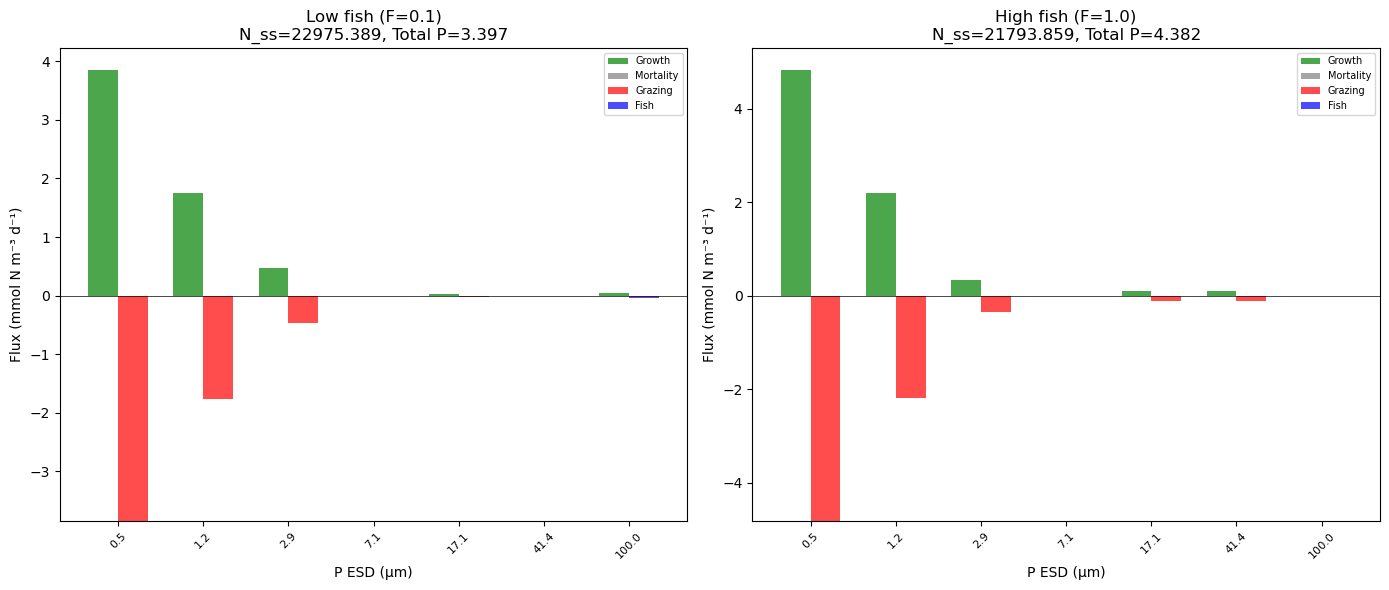

In [3]:

# =====================================================================
# PLOT 4: Steady-state growth-loss budget from model run
# =====================================================================

# Run two scenarios: low and high fish
scenarios = {
    'Low fish (F=0.1)':  {'N0__value': 5.0, 'FishForcing__value': 0.1},
    'High fish (F=1.0)': {'N0__value': 5.0, 'FishForcing__value': 1.0},
}

fig, axes = plt.subplots(1, len(scenarios), figsize=(7 * len(scenarios), 6))
if len(scenarios) == 1:
    axes = [axes]

for ax, (label, params) in zip(axes, scenarios.items()):
    out = run_model_test(params, time=np.arange(0, 5000))

    P_ss = out.Phytoplankton__biomass.isel(time=-1).values
    Z_ss = out.Zooplankton__biomass.isel(time=-1).values
    N_ss = out.Nutrient__value.isel(time=-1).values.item()
    F_val = params['FishForcing__value']

    # Growth
    growth = mu_max * N_ss / (N_ss + K_s) * P_ss

    # Mortality
    mort = m_P * P_ss

    # Grazing loss on P (Type III)
    biomass = np.concatenate([P_ss, Z_ss])
    S_prey = np.sum(phiPZ * biomass[:, None], axis=0)
    G = (I_max * Z_ss * phiPZ * biomass[:, None]
         * S_prey / (S_prey ** 2 + KsZ ** 2))
    graze_loss_P = np.sum(G[:n_P, :], axis=1)

    # Fish loss on P
    fish_loss_P = w_P * fish_rate * F_val * P_ss

    # Plot stacked bars
    x = np.arange(n_P)
    width = 0.35

    # Gains (positive)
    ax.bar(x - width / 2, growth, width, color='green', alpha=0.7, label='Growth')

    # Losses (negative, stacked)
    ax.bar(x + width / 2, -mort, width, color='grey', alpha=0.7, label='Mortality')
    ax.bar(x + width / 2, -graze_loss_P, width, bottom=-mort,
           color='red', alpha=0.7, label='Grazing')
    ax.bar(x + width / 2, -fish_loss_P, width, bottom=-mort - graze_loss_P,
           color='blue', alpha=0.7, label='Fish')

    ax.axhline(0, color='k', lw=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{e:.1f}' for e in phyto_esd], rotation=45, fontsize=8)
    ax.set_xlabel('P ESD (µm)')
    ax.set_ylabel('Flux (mmol N m⁻³ d⁻¹)')
    ax.set_title(f'{label}\nN_ss={N_ss:.3f}, Total P={P_ss.sum():.3f}')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('tradeoff_4_budget_steady_state.png', dpi=150)
plt.show()

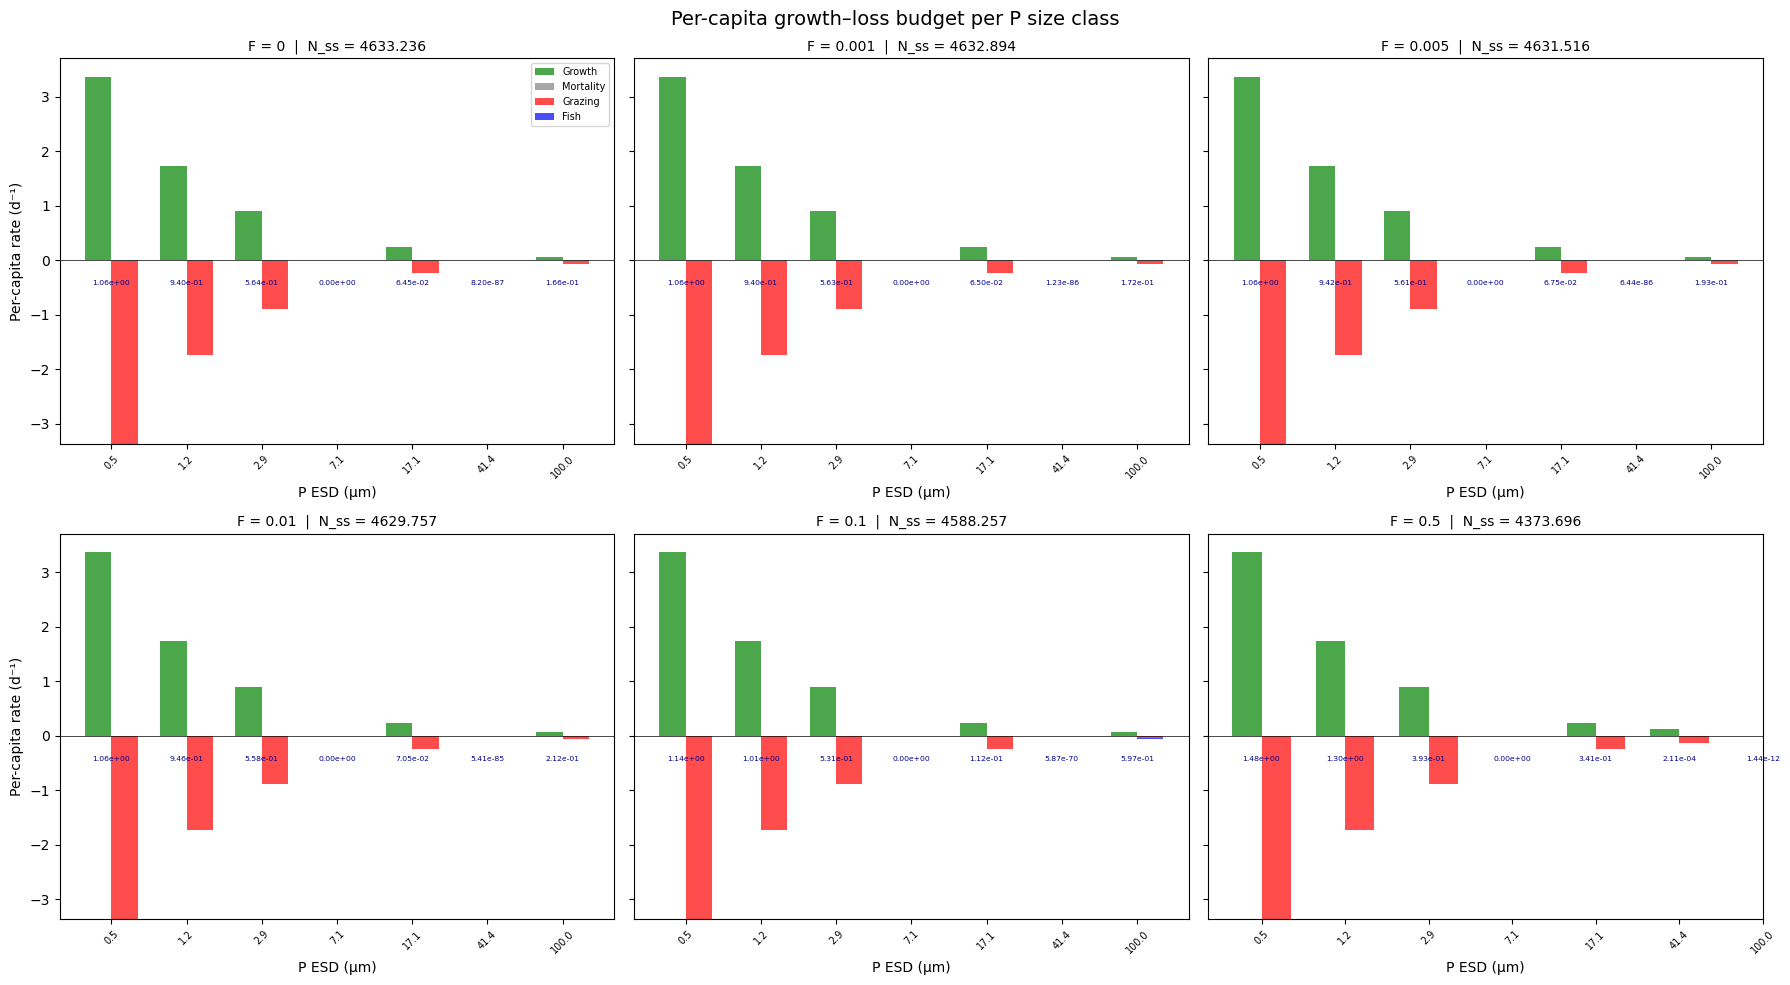

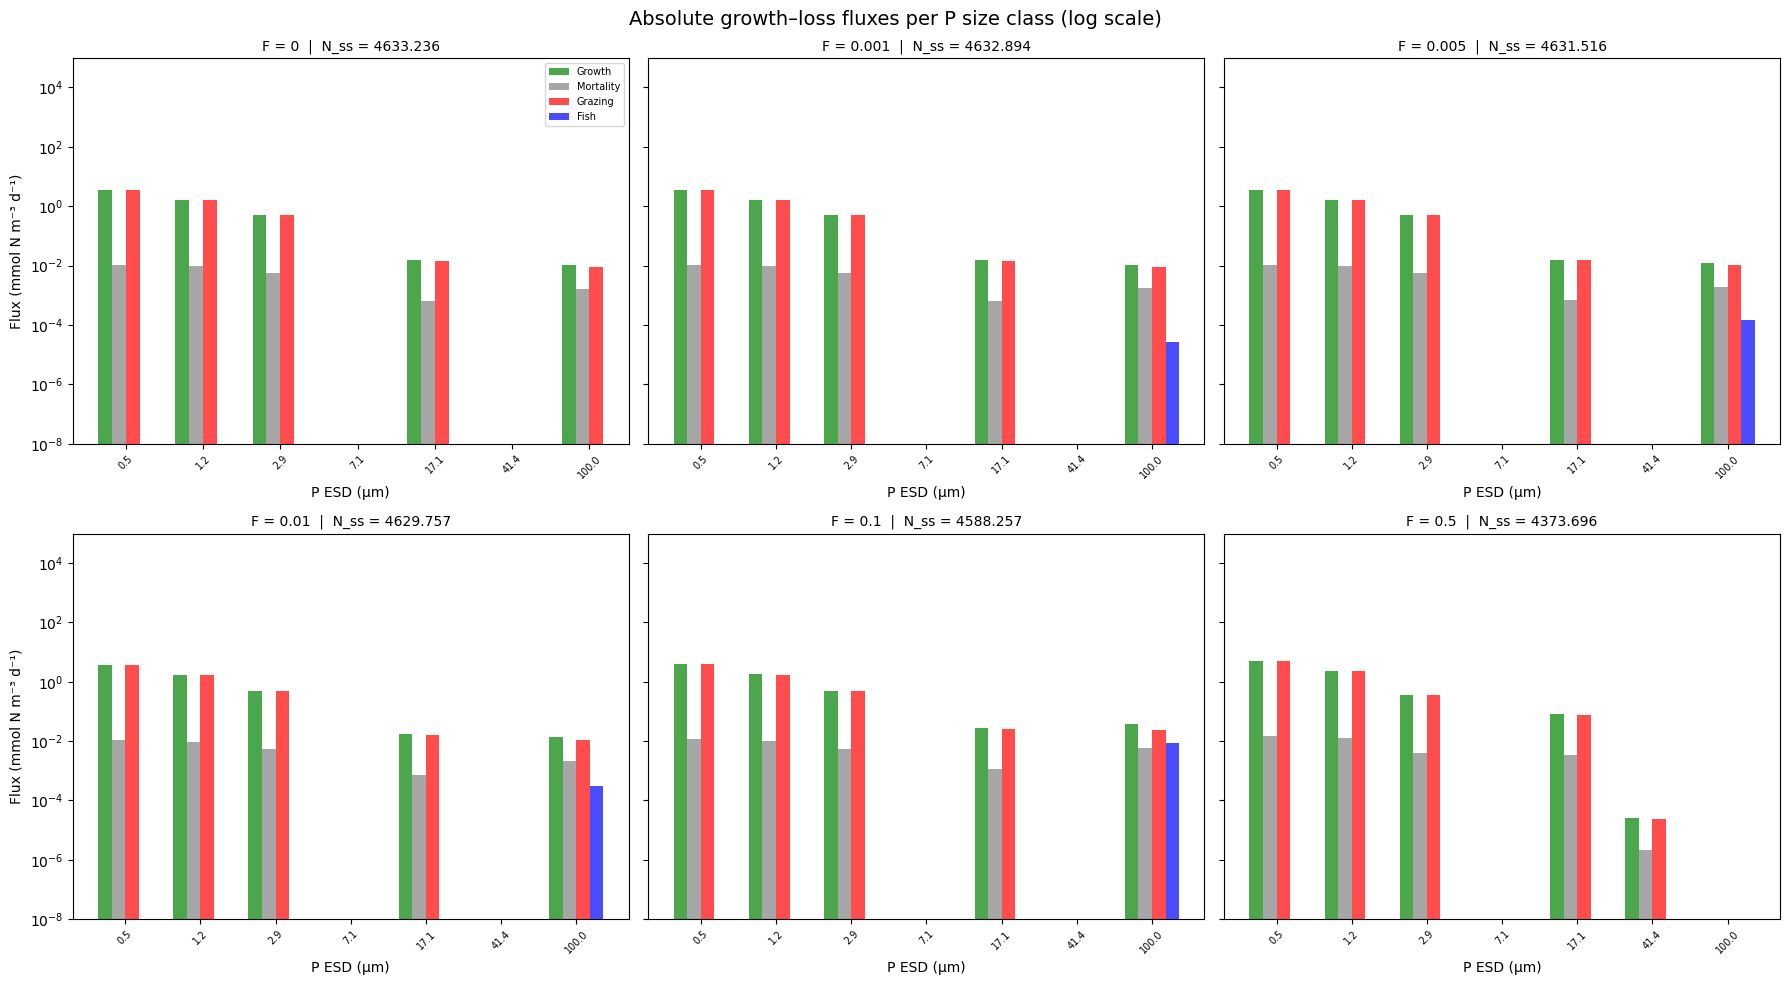


Steady-state P biomass across fish forcing scenarios
  ESD (µm)         F=0     F=0.001     F=0.005      F=0.01       F=0.1       F=0.5
----------------------------------------------------------------------------------
       0.5  1.0557e+00  1.0564e+00  1.0593e+00  1.0636e+00  1.1437e+00  1.4811e+00
       1.2  9.3956e-01  9.4010e-01  9.4249e-01  9.4624e-01  1.0137e+00  1.2997e+00
       2.9  5.6371e-01  5.6320e-01  5.6074e-01  5.5787e-01  5.3114e-01  3.9342e-01
       7.1  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
      17.1  6.4461e-02  6.4984e-02  6.7473e-02  7.0524e-02  1.1226e-01  3.4085e-01
      41.4  8.1983e-87  1.2313e-86  6.4389e-86  5.4128e-85  5.8747e-70  2.1053e-04
     100.0  1.6598e-01  1.7216e-01  1.9325e-01  2.1209e-01  5.9708e-01  1.4352e-12

Done. Saved: tradeoff_4a_percapita_budget.png, tradeoff_4b_absolute_log.png


In [8]:
"""
Tradeoff Plot 4 (revised): Steady-state growth-loss budgets
============================================================
Figure A: Per-capita rates across fish forcing scenarios
Figure B: Absolute fluxes (log-scale) across fish forcing scenarios
"""

import numpy as np
import matplotlib.pyplot as plt

from npxzxf_models import (
    run_model_test,
    phyto_esd, zoo_esd,
    mu_max, K_s, m_P,
    I_max, gge, m_Z,
    phiPZ, w_P, w_Z,
    BASE_INPUT_VARS,
)

n_P = len(phyto_esd)
n_Z = len(zoo_esd)
KsZ = BASE_INPUT_VARS['Grazing']['KsZ']
fish_rate = BASE_INPUT_VARS['FishGrazing']['rate']

N0_val = 5.0
F_values = [0, 0.001, 0.005, 0.01, 0.1, 0.5]
n_scenarios = len(F_values)


def compute_P_budget(P_ss, Z_ss, N_ss, F_val):
    """Compute absolute and per-capita flux budgets for P."""
    biomass = np.concatenate([P_ss, Z_ss])
    S_prey = np.sum(phiPZ * biomass[:, None], axis=0)
    G = (I_max * Z_ss * phiPZ * biomass[:, None]
         * S_prey / (S_prey ** 2 + KsZ ** 2))

    growth      = mu_max * N_ss / (N_ss + K_s) * P_ss
    mort        = m_P * P_ss
    graze_loss  = np.sum(G[:n_P, :], axis=1)
    fish_loss   = w_P * fish_rate * F_val * P_ss

    # Per-capita: divide by biomass (guard against zero)
    B_safe = np.where(P_ss > 1e-10, P_ss, np.nan)
    pc_growth     = growth / B_safe
    pc_mort       = mort / B_safe
    pc_graze      = graze_loss / B_safe
    pc_fish       = fish_loss / B_safe

    return {
        'growth': growth, 'mort': mort, 'graze': graze_loss, 'fish': fish_loss,
        'pc_growth': pc_growth, 'pc_mort': pc_mort,
        'pc_graze': pc_graze, 'pc_fish': pc_fish,
        'P_ss': P_ss, 'N_ss': N_ss,
    }


# --- Run all scenarios ---
results = {}
for F_val in F_values:
    out = run_model_test({'N0__value': N0_val, 'FishForcing__value': F_val},
                         time=np.arange(0, 1000))
    P_ss = out.Phytoplankton__biomass.isel(time=-1).values
    Z_ss = out.Zooplankton__biomass.isel(time=-1).values
    N_ss = out.Nutrient__value.isel(time=-1).values.item()
    results[F_val] = compute_P_budget(P_ss, Z_ss, N_ss, F_val)


# =====================================================================
# FIGURE A: Per-capita rates
# =====================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
fig.suptitle('Per-capita growth–loss budget per P size class', fontsize=14)

x = np.arange(n_P)
width = 0.35

for ax, F_val in zip(axes.flat, F_values):
    r = results[F_val]
    
    # Gains
    ax.bar(x - width / 2, r['pc_growth'], width,
           color='green', alpha=0.7, label='Growth')

    # Losses (stacked negative)
    ax.bar(x + width / 2, -r['pc_mort'], width,
           color='grey', alpha=0.7, label='Mortality')
    ax.bar(x + width / 2, -r['pc_graze'], width, bottom=-r['pc_mort'],
           color='red', alpha=0.7, label='Grazing')
    ax.bar(x + width / 2, -r['pc_fish'], width,
           bottom=-r['pc_mort'] - r['pc_graze'],
           color='blue', alpha=0.7, label='Fish')

    ax.axhline(0, color='k', lw=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{e:.1f}' for e in phyto_esd], rotation=45, fontsize=7)
    ax.set_xlabel('P ESD (µm)')

    # Annotate biomass below each bar
    for i in range(n_P):
        ax.annotate(f'{r["P_ss"][i]:.2e}', (x[i], 0),
                    textcoords='offset points', xytext=(0, -18),
                    ha='center', fontsize=5.5, color='darkblue')

    ax.set_title(f'F = {F_val}  |  N_ss = {r["N_ss"]:.3f}', fontsize=10)
    

axes[0, 0].set_ylabel('Per-capita rate (d⁻¹)')
axes[1, 0].set_ylabel('Per-capita rate (d⁻¹)')
axes[0, 0].legend(fontsize=7)

plt.tight_layout()
plt.savefig('tradeoff_4a_percapita_budget.png', dpi=150)
plt.show()


# =====================================================================
# FIGURE B: Absolute fluxes (log-scale)
# =====================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
fig.suptitle('Absolute growth–loss fluxes per P size class (log scale)', fontsize=14)

for ax, F_val in zip(axes.flat, F_values):
    r = results[F_val]

    # Plot gains and losses as separate positive bars side by side
    bar_w = 0.18
    offsets = [-1.5 * bar_w, -0.5 * bar_w, 0.5 * bar_w, 1.5 * bar_w]
    colors = ['green', 'grey', 'red', 'blue']
    labels = ['Growth', 'Mortality', 'Grazing', 'Fish']
    values = [r['growth'], r['mort'], r['graze'], r['fish']]

    for off, col, lab, val in zip(offsets, colors, labels, values):
        # Replace zeros with tiny value for log scale visibility
        val_plot = np.where(val > 0, val, np.nan)
        ax.bar(x + off, val_plot, bar_w, color=col, alpha=0.7, label=lab)

    ax.set_yscale('log')
    ax.set_ylim(1e-8, None)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{e:.1f}' for e in phyto_esd], rotation=45, fontsize=7)
    ax.set_xlabel('P ESD (µm)')
    ax.set_title(f'F = {F_val}  |  N_ss = {r["N_ss"]:.3f}', fontsize=10)

axes[0, 0].set_ylabel('Flux (mmol N m⁻³ d⁻¹)')
axes[1, 0].set_ylabel('Flux (mmol N m⁻³ d⁻¹)')
axes[0, 0].legend(fontsize=7)

plt.tight_layout()
plt.savefig('tradeoff_4b_absolute_log.png', dpi=150)
plt.show()


# =====================================================================
# SUMMARY TABLE: Print steady-state biomass across scenarios
# =====================================================================

print("\n" + "=" * 70)
print("Steady-state P biomass across fish forcing scenarios")
print("=" * 70)
header = f"{'ESD (µm)':>10}" + "".join(f"{'F='+str(f):>12}" for f in F_values)
print(header)
print("-" * len(header))
for i in range(n_P):
    row = f"{phyto_esd[i]:10.1f}"
    for F_val in F_values:
        row += f"{results[F_val]['P_ss'][i]:12.4e}"
    print(row)

print("\nDone. Saved: tradeoff_4a_percapita_budget.png, tradeoff_4b_absolute_log.png")

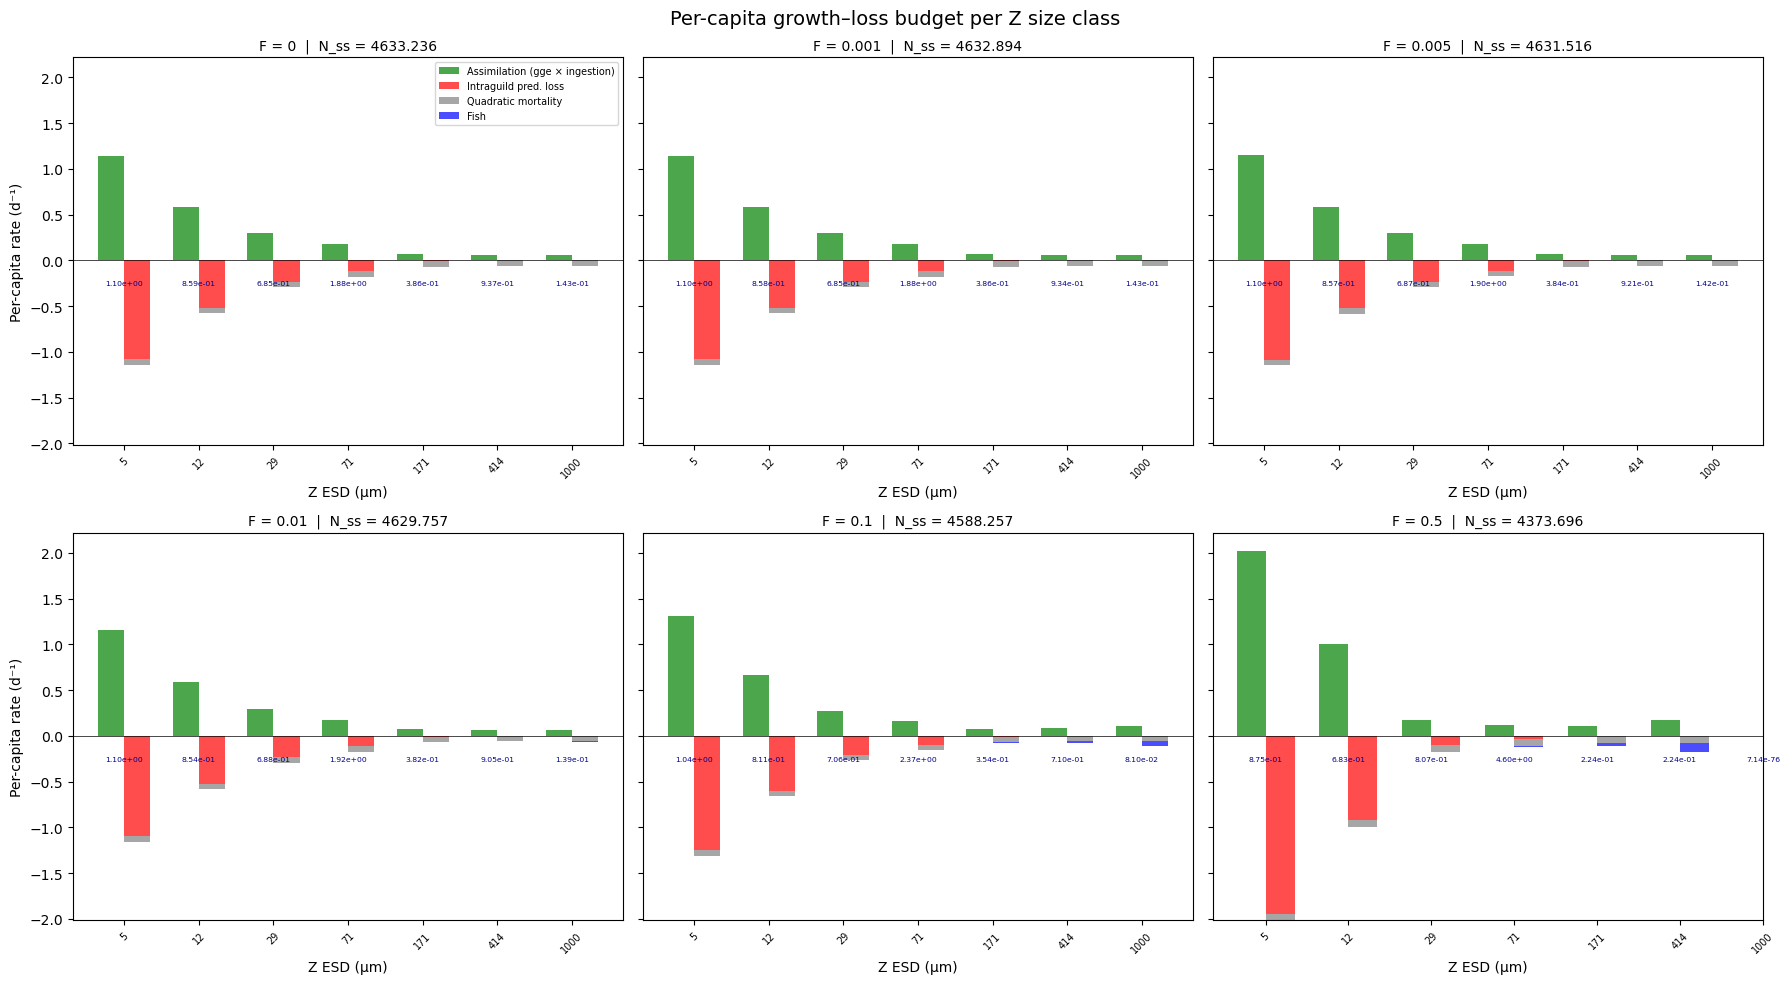

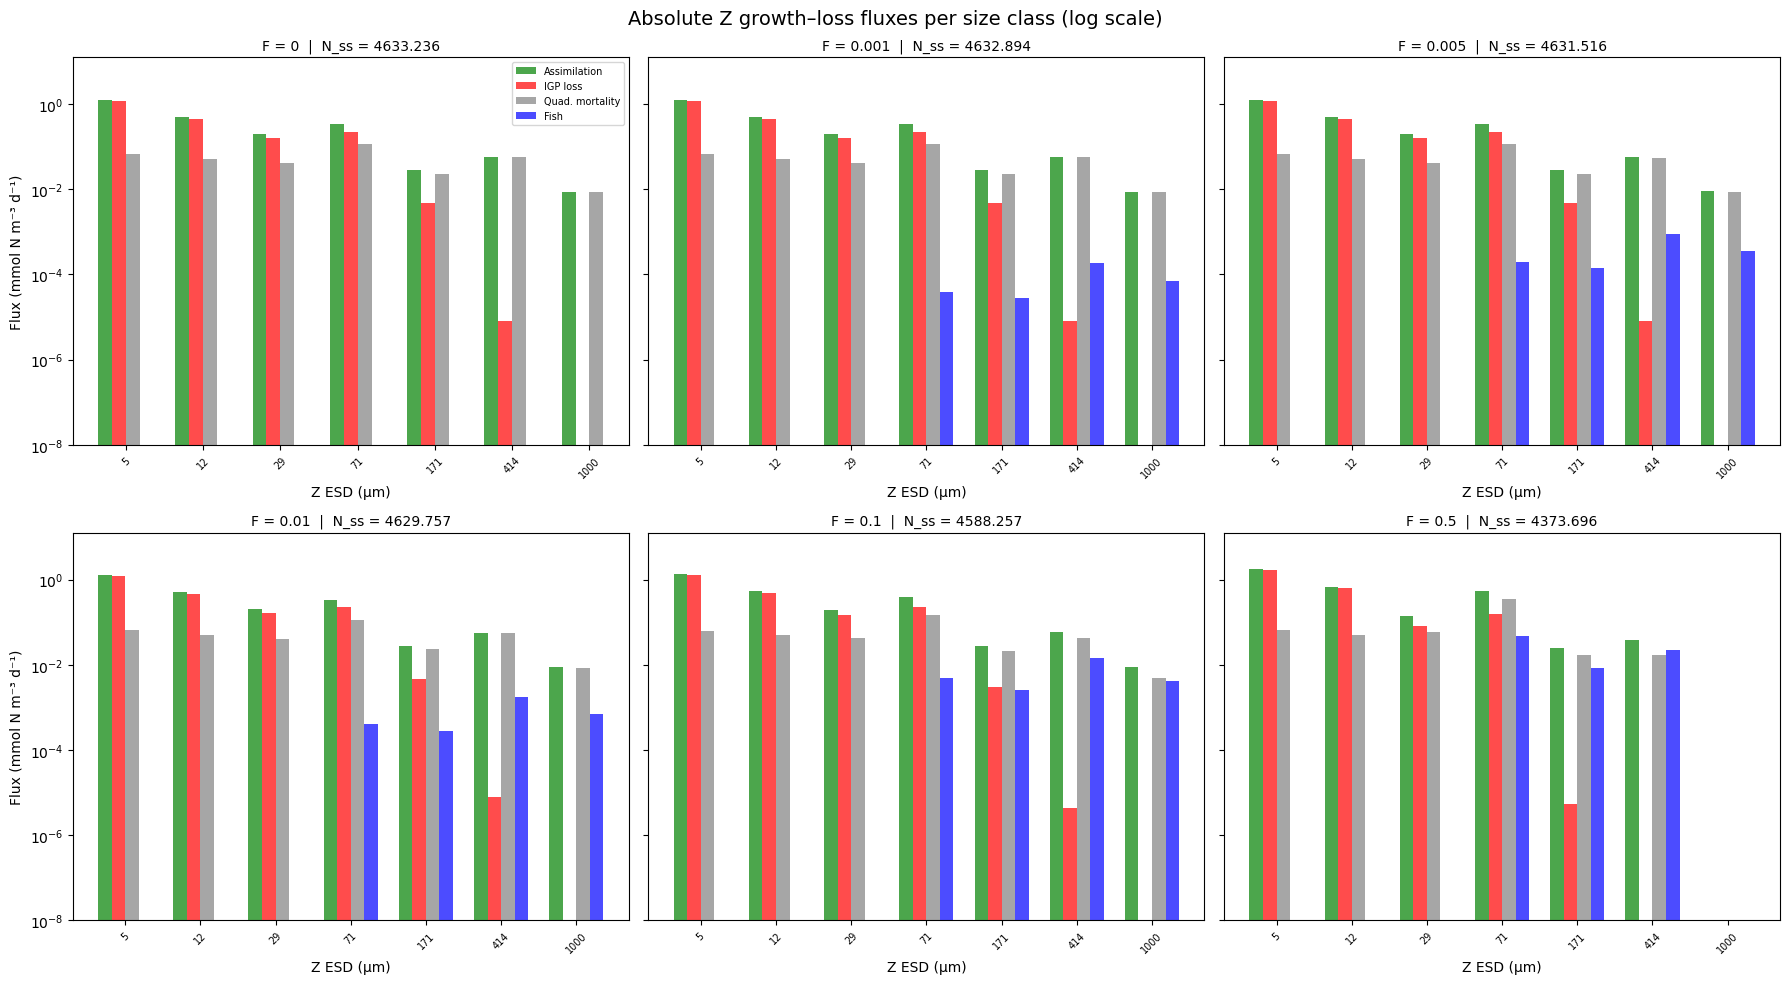


Steady-state Z biomass across fish forcing scenarios
  ESD (µm)         F=0     F=0.001     F=0.005      F=0.01       F=0.1       F=0.5
----------------------------------------------------------------------------------
         5  1.1025e+00  1.1020e+00  1.0997e+00  1.0963e+00  1.0385e+00  8.7503e-01
        12  8.5878e-01  8.5840e-01  8.5676e-01  8.5419e-01  8.1089e-01  6.8309e-01
        29  6.8470e-01  6.8503e-01  6.8659e-01  6.8841e-01  7.0606e-01  8.0690e-01
        71  1.8781e+00  1.8818e+00  1.8973e+00  1.9206e+00  2.3710e+00  4.5971e+00
       171  3.8606e-01  3.8557e-01  3.8383e-01  3.8234e-01  3.5432e-01  2.2446e-01
       414  9.3732e-01  9.3446e-01  9.2143e-01  9.0467e-01  7.0979e-01  2.2434e-01
      1000  1.4346e-01  1.4295e-01  1.4172e-01  1.3946e-01  8.1029e-02  7.1381e-76

Done. Saved: tradeoff_4a_Z_percapita_budget.png, tradeoff_4b_Z_absolute_log.png


In [7]:
"""
Tradeoff Plot 4 (revised): Steady-state Z growth-loss budgets
==============================================================
Figure A: Per-capita rates across fish forcing scenarios
Figure B: Absolute fluxes (log-scale) across fish forcing scenarios
"""

import numpy as np
import matplotlib.pyplot as plt

from npxzxf_models import (
    run_model_test,
    phyto_esd, zoo_esd,
    mu_max, K_s, m_P,
    I_max, gge, m_Z,
    phiPZ, w_P, w_Z,
    BASE_INPUT_VARS,
)

n_P = len(phyto_esd)
n_Z = len(zoo_esd)
KsZ = BASE_INPUT_VARS['Grazing']['KsZ']
fish_rate = BASE_INPUT_VARS['FishGrazing']['rate']

N0_val = 5.0
F_values = [0, 0.001, 0.005, 0.01, 0.1, 0.5]
n_scenarios = len(F_values)


def compute_Z_budget(P_ss, Z_ss, N_ss, F_val):
    """Compute absolute and per-capita flux budgets for Z."""
    biomass = np.concatenate([P_ss, Z_ss])
    S_prey = np.sum(phiPZ * biomass[:, None], axis=0)
    G = (I_max * Z_ss * phiPZ * biomass[:, None]
         * S_prey / (S_prey ** 2 + KsZ ** 2))

    # Assimilation: gge * total ingested per predator
    total_ingested = np.sum(G, axis=0)  # (n_Z,)
    assimilation = total_ingested * gge

    # Intraguild predation loss on Z (rows n_P: of G, summed over predators)
    igp_loss = np.sum(G[n_P:, :], axis=1)

    # Quadratic mortality: m_Z * Z_i * sum(Z)
    quad_mort = m_Z * Z_ss * np.sum(Z_ss)

    # Fish loss
    fish_loss = w_Z * fish_rate * F_val * Z_ss

    # Per-capita
    B_safe = np.where(Z_ss > 1e-10, Z_ss, np.nan)
    pc_assim    = assimilation / B_safe
    pc_igp      = igp_loss / B_safe
    pc_mort     = quad_mort / B_safe
    pc_fish     = fish_loss / B_safe

    return {
        'assim': assimilation, 'igp': igp_loss,
        'mort': quad_mort, 'fish': fish_loss,
        'pc_assim': pc_assim, 'pc_igp': pc_igp,
        'pc_mort': pc_mort, 'pc_fish': pc_fish,
        'Z_ss': Z_ss, 'N_ss': N_ss,
    }


# --- Run all scenarios ---
results = {}
for F_val in F_values:
    out = run_model_test({'N0__value': N0_val, 'FishForcing__value': F_val},
                         time=np.arange(0, 1000))
    P_ss = out.Phytoplankton__biomass.isel(time=-1).values
    Z_ss = out.Zooplankton__biomass.isel(time=-1).values
    N_ss = out.Nutrient__value.isel(time=-1).values.item()
    results[F_val] = compute_Z_budget(P_ss, Z_ss, N_ss, F_val)


# =====================================================================
# FIGURE A: Per-capita rates
# =====================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
fig.suptitle('Per-capita growth–loss budget per Z size class', fontsize=14)

x = np.arange(n_Z)
width = 0.35

for ax, F_val in zip(axes.flat, F_values):
    r = results[F_val]

    # Gain
    ax.bar(x - width / 2, r['pc_assim'], width,
           color='green', alpha=0.7, label='Assimilation (gge × ingestion)')

    # Losses (stacked negative)
    ax.bar(x + width / 2, -r['pc_igp'], width,
           color='red', alpha=0.7, label='Intraguild pred. loss')
    ax.bar(x + width / 2, -r['pc_mort'], width, bottom=-r['pc_igp'],
           color='grey', alpha=0.7, label='Quadratic mortality')
    ax.bar(x + width / 2, -r['pc_fish'], width,
           bottom=-r['pc_igp'] - r['pc_mort'],
           color='blue', alpha=0.7, label='Fish')

    ax.axhline(0, color='k', lw=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{e:.0f}' for e in zoo_esd], rotation=45, fontsize=7)
    ax.set_xlabel('Z ESD (µm)')

    for i in range(n_Z):
        ax.annotate(f'{r["Z_ss"][i]:.2e}', (x[i], 0),
                    textcoords='offset points', xytext=(0, -18),
                    ha='center', fontsize=5.5, color='darkblue')

    ax.set_title(f'F = {F_val}  |  N_ss = {r["N_ss"]:.3f}', fontsize=10)

axes[0, 0].set_ylabel('Per-capita rate (d⁻¹)')
axes[1, 0].set_ylabel('Per-capita rate (d⁻¹)')
axes[0, 0].legend(fontsize=7)

plt.tight_layout()
plt.savefig('tradeoff_4a_Z_percapita_budget.png', dpi=150)
plt.show()


# =====================================================================
# FIGURE B: Absolute fluxes (log-scale)
# =====================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
fig.suptitle('Absolute Z growth–loss fluxes per size class (log scale)', fontsize=14)

for ax, F_val in zip(axes.flat, F_values):
    r = results[F_val]

    bar_w = 0.18
    offsets = [-1.5 * bar_w, -0.5 * bar_w, 0.5 * bar_w, 1.5 * bar_w]
    colors = ['green', 'red', 'grey', 'blue']
    labels = ['Assimilation', 'IGP loss', 'Quad. mortality', 'Fish']
    values = [r['assim'], r['igp'], r['mort'], r['fish']]

    for off, col, lab, val in zip(offsets, colors, labels, values):
        val_plot = np.where(val > 0, val, np.nan)
        ax.bar(x + off, val_plot, bar_w, color=col, alpha=0.7, label=lab)

    ax.set_yscale('log')
    ax.set_ylim(1e-8, None)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{e:.0f}' for e in zoo_esd], rotation=45, fontsize=7)
    ax.set_xlabel('Z ESD (µm)')
    ax.set_title(f'F = {F_val}  |  N_ss = {r["N_ss"]:.3f}', fontsize=10)

axes[0, 0].set_ylabel('Flux (mmol N m⁻³ d⁻¹)')
axes[1, 0].set_ylabel('Flux (mmol N m⁻³ d⁻¹)')
axes[0, 0].legend(fontsize=7)

plt.tight_layout()
plt.savefig('tradeoff_4b_Z_absolute_log.png', dpi=150)
plt.show()


# =====================================================================
# SUMMARY TABLE
# =====================================================================

print("\n" + "=" * 70)
print("Steady-state Z biomass across fish forcing scenarios")
print("=" * 70)
header = f"{'ESD (µm)':>10}" + "".join(f"{'F='+str(f):>12}" for f in F_values)
print(header)
print("-" * len(header))
for i in range(n_Z):
    row = f"{zoo_esd[i]:10.0f}"
    for F_val in F_values:
        row += f"{results[F_val]['Z_ss'][i]:12.4e}"
    print(row)

print("\nDone. Saved: tradeoff_4a_Z_percapita_budget.png, tradeoff_4b_Z_absolute_log.png")